# tACS Bandit: Main Analyses

**Study:** Examining the effects of theta-tACS over left DLPFC on reward-based learning across the adult lifespan

**Design:** Within-subject crossover (active vs. sham theta-tACS, 6 Hz)

This notebook orchestrates all pre-registered and exploratory analyses by calling modular functions. Individual modules contain the implementation details.

---
## 0. Setup & Imports

In [3]:
# Standard
import numpy as np
import pandas as pd
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Visualization
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.templates.default = 'plotly_white'

# Project modules
from config import *
from data_loading import load_all_subjects, summarize_loading
from exclusions import apply_all_exclusions
from sample_descriptives import run_sample_descriptives
from blinding_analysis import run_blinding_analysis
from wsls import run_wsls_analysis
from reversal_analysis import run_reversal_analysis
from rescorla_wagner import run_rw_analysis
from ddm import run_ddm_analysis
from cognitive_merge import run_cognitive_merge
from hypothesis_tests import run_hypothesis_tests
from order_effects import run_order_effects_analysis
from correlations import run_correlation_analysis

print(f'Study: {len(SUBJECT_INFO)} participants in SUBJECT_INFO')
print(f'Data directory: {DATA_DIR}')

Study: 31 participants in SUBJECT_INFO
Data directory: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/data/bandit


---
## 1. Data Loading & Preprocessing

In [5]:
# Load all behavioral data
data = load_all_subjects()
summarize_loading(data)

Loading sub-10369...
  Run 1: 67 trials, 4 missed
  Run 2: 68 trials, 2 missed
  Run 3: 74 trials, 0 missed
  Run 4: 77 trials, 0 missed
  Run 5: 79 trials, 0 missed
  Run 6: 76 trials, 1 missed
  Run 7: 76 trials, 0 missed
  Run 8: 77 trials, 0 missed
Loading sub-10418...
  Run 1: 73 trials, 0 missed
  Run 2: 71 trials, 0 missed
  Run 3: 73 trials, 0 missed
  Run 4: 73 trials, 0 missed
  Run 5: 74 trials, 0 missed
  Run 6: 73 trials, 0 missed
  Run 7: 70 trials, 1 missed
  Run 8: 69 trials, 0 missed
Loading sub-10541...
  Run 1: 70 trials, 2 missed
  Run 2: 69 trials, 1 missed
  Run 3: 70 trials, 4 missed
  Run 4: 71 trials, 5 missed
  Run 5: 72 trials, 0 missed
  Run 6: 72 trials, 2 missed
  Run 7: 73 trials, 1 missed
  Run 8: 71 trials, 2 missed
Loading sub-10559...
  Run 1: 72 trials, 2 missed
  Run 2: 72 trials, 4 missed
  Run 3: 76 trials, 1 missed
  Run 4: 77 trials, 0 missed
  Run 5: 77 trials, 0 missed
  Run 6: 75 trials, 1 missed
  Run 7: 74 trials, 2 missed
  Run 8: 73 trial

,subject_id,n_runs,n_trials,n_missed,pct_missed,counterbalance,conditions
0,10369,8,594,7,1.178451,B,"[active, baseline, post, sham]"
1,10418,8,576,1,0.173611,B,"[active, baseline, post, sham]"
2,10541,8,568,17,2.992958,B,"[active, baseline, post, sham]"
3,10559,8,596,13,2.181208,A,"[active, baseline, post, sham]"
4,10589,8,597,3,0.502513,A,"[active, baseline, post, sham]"
5,10606,8,598,2,0.334448,A,"[active, baseline, post, sham]"
6,10608,8,586,3,0.511945,A,"[active, baseline, post, sham]"
7,10636,8,611,3,0.490998,B,"[active, baseline, post, sham]"
8,10638,8,578,10,1.730104,B,"[active, baseline, post, sham]"
9,10641,8,593,3,0.505902,B,"[active, baseline, post, sham]"


In [6]:
# Apply exclusion criteria
exclusion_results = apply_all_exclusions(data)

# Extract filtered datasets
data_h1 = exclusion_results['data_h1']       # H1 analyses: sham only, behavioral exclusions
data_h2 = exclusion_results['data_h2']       # H2 analyses: active vs sham, all exclusions
data_clean = exclusion_results['data_clean'] # All clean trials
run_exclusions = exclusion_results['run_exclusions']
h2_eligible = exclusion_results['h2_eligible']

print(f'\nH1-eligible subjects: {data_h1["subject_id"].nunique()}')
print(f'H2-eligible subjects: {len(h2_eligible)}')

Computing Pre-Registered Exclusion Criteria

Behavioral Exclusion Summary (Run-Level):
--------------------------------------------------
  ⚠ >20% missed trials: 1/232 runs (0%)
  ⚠ Side bias (>95%): 3/232 runs (1%)
  ⚠ Stimulus bias (>95%): 6/232 runs (3%)
  ⚠ Rapid responding (<200ms): 1/232 runs (0%)
  ⚠ Feedback invariance (10+ losses): 2/232 runs (1%)

Stimulation Administration Exclusions: 3 runs
  sub-10998 Run 6: Experimenter error: sham protocol loaded instead of active
  sub-11773 Run 6: Experimenter error: sham protocol loaded instead of active
  sub-11773 Run 7: Experimenter error: sham protocol loaded instead of active

Combined Exclusion Summary

Total subjects: 29
Total runs: 232
Runs excluded (behavioral): 12
Runs excluded (stim admin): 3
Unique runs excluded for H2: 14

H1 sample (sham, behavioral exclusions):
  29 subjects, 57 clean sham runs, 4207 trials

H2 sample (active vs. sham, all exclusions + min-run threshold):
  27 subjects eligible for paired comparisons, 7

---
## 2. Sample Descriptives & Demographics

Sample Descriptives

N = 31
Age: M = 44.7, SD = 19.5, range = 23–75

Gender:
  Female: 17 (55%)
  Male: 14 (45%)

Race:
  White: 24 (77%)
  Black or African American: 4 (13%)
  Asian: 2 (6%)
  Two or more races, or race not described (other): 1 (3%)

Ethnicity:
  Not Hispanic or Latino: 28 (90%)
  Hispanic or Latino: 3 (10%)



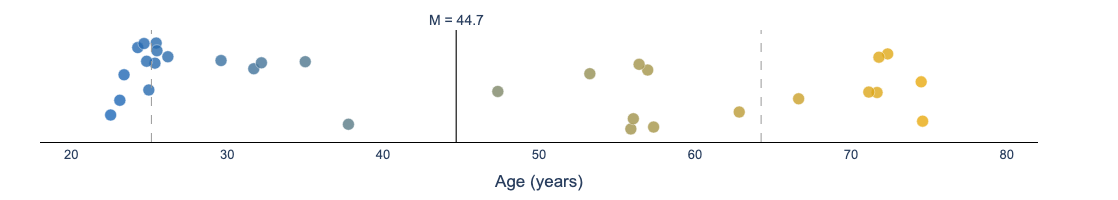


Estimated vs Actual Cap Size Comparison

Subjects with ICV data: 31
Subjects with both estimated and actual: 25
  Matches (same size): 15
  Off by 1 size: 9
  Off by 2 sizes: 1

Mismatch direction:
  Actual smaller than estimated: 9
  Actual larger than estimated: 1

 Subject      ICV      Estimated       Actual       Status
------------------------------------------------------------
   10369   1534.5          Large        Large      ✓ Match
   10418   1329.0              —       Medium   Incomplete
   10541   1614.6    Extra Large        Large    ✗ +1 size
   10559   1443.6          Large        Large      ✓ Match
   10589   1494.2          Large            —   Incomplete
   10606   1489.6          Large        Large      ✓ Match
   10608   1197.5          Small        Small      ✓ Match
   10636   1313.4              —        Small   Incomplete
   10638   1235.7          Small        Small      ✓ Match
   10641   1313.5          Small        Small      ✓ Match
   10649   1395.5    

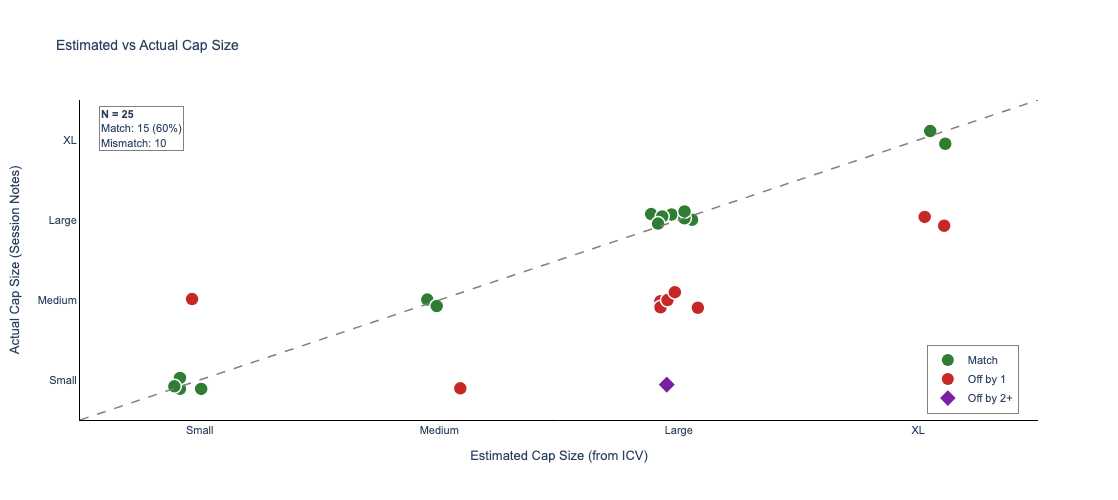

In [8]:
# Demographics and cap size analysis
desc_results = run_sample_descriptives()

---
## 3. Blinding Integrity

Blinding Integrity Analysis

Data: 109 run-level observations from 29 participants

--- Contingency Table ---
                 Participant Guess
Actual Condition   Active    Sham    Total
---------------------------------------------
     Active            39       16       55
      Sham             31       23       54
---------------------------------------------
     Total             70       39      109

--- Signal Detection Metrics ---
  Hits (say Active | Active):            39 / 55 = 70.9%
  Misses (say Sham | Active):            16 / 55 = 29.1%
  False Alarms (say Active | Sham):      31 / 54 = 57.4%
  Correct Rejections (say Sham | Sham):  23 / 54 = 42.6%

  d' (sensitivity):  +0.36  (near zero — no discrimination)
  c (criterion):     -0.36  (bias toward "Active")

  Overall accuracy: 56.9% (62/109)
  Binomial vs 50%: p = 0.180
  χ² = 1.61, p = 0.204

--- By Counterbalance Order ---
Order    N_runs        Hits          FA       d'      Acc
-----------------------------------

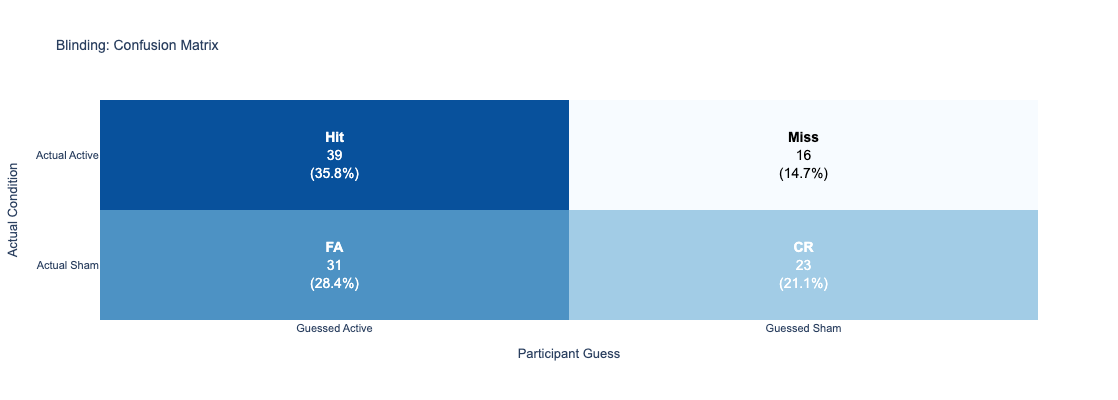

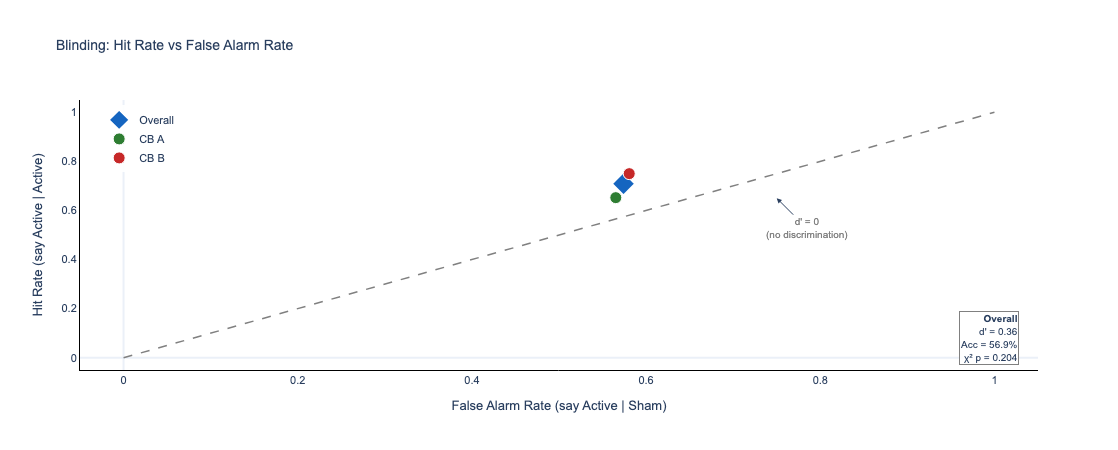


✓ Blinding appears intact


In [14]:
# Signal detection analysis of blinding
blinding_results = run_blinding_analysis(data_clean)

if blinding_results['blinding_intact']:
    print('\n✓ Blinding appears intact')
else:
    print('\n⚠ Blinding may be compromised — interpret with caution')

---
## 4. Win-Stay / Lose-Shift Analysis

H1 WSLS (sham, clean runs):
subject_id  p_stay_win  p_shift_lose  n_win_trials  n_lose_trials  n_total_trials
     10369    0.591549      0.507692            71             65             136
     10418    0.959459      0.500000            74             68             142
     10541    0.945946      0.648148            74             54             128
     10559    0.881579      0.353846            76             65             141
     10589    0.913462      0.369565           104             46             150
     10606    0.439024      0.470588            41             34              75
     10608    0.976744      0.677966            86             59             145
     10636    0.989796      0.395833            98             48             146
     10638    0.459459      0.420290            74             69             143
     10641    0.873418      0.606557            79             61             140
     10649    0.987952      0.508475            83             59     

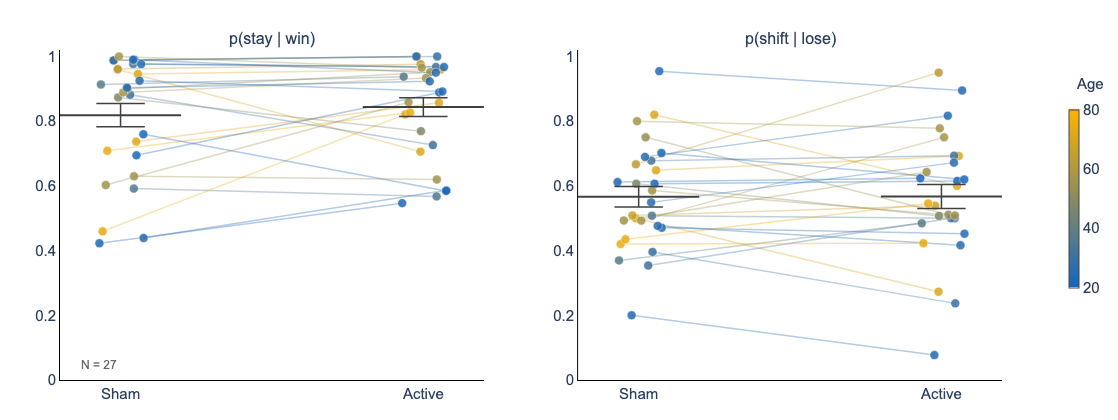

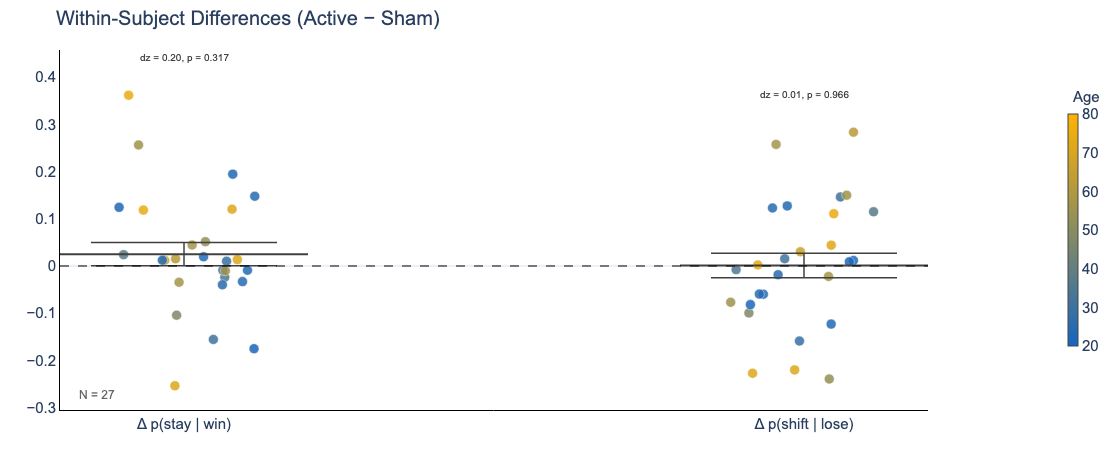

In [17]:
# WSLS analysis for H1 and H2
wsls_results = run_wsls_analysis(data_h1, data_h2, data)

---
## 5. Reversal Learning Analysis

In [20]:
# Reversal-locked accuracy and trials to criterion
rev_results = run_reversal_analysis(data, data_clean, data_h1, data_h2)

Identified 466 reversals across 29 subjects
Trials in reversal windows: 9691 / 17142

Reversals per subject × condition:
condition   active  baseline  post  sham
subject_id                              
10369            4         4     4     4
10418            4         4     4     4
10541            4         4     4     4
10559            4         4     4     4
10589            4         4     4     4
10606            4         4     4     4
10608            4         4     4     4
10636            4         4     4     4
10638            4         4     4     4
10641            4         4     4     4
10649            4         4     4     4
10656            4         4     4     4
10661            4         4     4     4
10716            4         4     5     4
10809            4         4     4     4
10862            4         4     4     4
10866            4         4     4     4
10886            4         4     4     4
10951            5         4     4     4
10998            4

TypeError: '<=' not supported between instances of 'str' and 'int'

---
## 6. Rescorla-Wagner Model

In [23]:
# Fit R-W model (MLE and MAP)
rw_results = run_rw_analysis(
    data_clean, 
    h2_subjects=h2_eligible,
    run_recovery=False  # Set True to run parameter recovery (slow)
)


Rescorla-Wagner Model Fitting

Fitted 57 subject × condition blocks

⚠ WARNING: 21 fits hit parameter boundaries

MLE vs MAP correlation: α = 0.940, β = 0.643

Subject-level fits: 29 subjects
  α: M = 0.651, SD = 0.389
  β: M = 4.22, SD = 7.99

--------------------------------------------------
Paired Comparison (H2 subjects)
--------------------------------------------------
  alpha: Δ = +0.054, dz = 0.16, t(26) = 0.82, p = 0.4213
  beta: Δ = +0.033, dz = 0.00, t(26) = 0.02, p = 0.9830


---
## 7. Drift Diffusion Model

In [26]:
# Fit DDM (requires pyddm)
ddm_results = run_ddm_analysis(
    data_clean,
    conditions=['sham', 'active'],
    run_bootstrap=False,  # Set True for bootstrap CI (slow)
    n_bootstrap=200
)

Drift Diffusion Model Analysis

DDM data preparation:
  Retained: 15864 trials (97.3%)
  Excluded: 441 trials
  Participants: 29
  Conditions: ['baseline', 'sham', 'active']

RT distribution (seconds):
  Mean: 0.629, Median: 0.542
  SD: 0.303

Overall accuracy: 63.9%

--------------------------------------------------
Condition-Level DDM Fits
--------------------------------------------------
  Fitting sham condition (n=3910 trials)...


Info: Params [0.29806272 0.76436316 0.22233383] gave 29996.753917926446


    v = 0.298, a = 0.764, t = 0.222s
  Fitting active condition (n=3965 trials)...


Info: Params [0.31672284 0.79627455 0.1802496 ] gave 31593.87413001872
Info: Params [0.39710004 0.88950549 0.14718352] gave 1348.7907104779738


    v = 0.317, a = 0.796, t = 0.180s

--------------------------------------------------
Condition Comparison
--------------------------------------------------
  v: sham = 0.298, active = 0.317, Δ = +0.019
  a: sham = 0.764, active = 0.796, Δ = +0.032
  t: sham = 0.222, active = 0.180, Δ = -0.042

--------------------------------------------------
Subject-Level DDM Fits
--------------------------------------------------


...

  Processing subject 20/29


Info: Params [0.28367338 0.87578648 0.13233587] gave 1134.9241644035742
Info: Params [0.31958029 0.67959964 0.25201079] gave 1071.6597617569437
Info: Params [0.33322724 0.7688345  0.2788266 ] gave 1186.4514979322414
Info: Params [0.14998261 0.70515628 0.23668838] gave 841.797231401223
Info: Params [0.39708292 0.6856354  0.30345994] gave 1136.400975506996
Info: Params [0.28339192 0.73220256 0.31798376] gave 1017.3620293013421
Info: Params [0.67899544 0.6761829  0.29842608] gave 693.4650391946769
Info: Params [0.45419935 0.68630324 0.27191443] gave 1227.1881519398669
Info: Params [0.37022325 0.72179945 0.27522824] gave 1139.68341286164
Info: Params [0.4131401  0.72743401 0.27781401] gave 1190.51735817159


  Processing subject 25/29


Info: Params [0.35695779 0.73109918 0.2381472 ] gave 604.9216707157763
Info: Params [0.30451979 0.71339853 0.21865331] gave 1118.6039703718866
Info: Params [0.5542215  0.67005817 0.19947745] gave 1349.3086200510916
Info: Params [0.43001732 0.672031   0.25079359] gave 1217.2650960428484
Info: Params [0.28821454 0.63935329 0.34042241] gave 963.7339342320698
Info: Params [0.26175986 0.69650044 0.3752107 ] gave 946.62526936229
Info: Params [0.28716219 0.74634554 0.31660609] gave 1067.827449256713
Info: Params [0.38487706 0.77599882 0.14552823] gave 1184.6645953692157
Info: Params [0.44609055 0.6450262  0.14754703] gave 381.08975139786753



  Complete cases (both conditions): 28

  V: Δ = +0.025, dz = 0.20, t = 1.08, p = 0.288

  A: Δ = -0.009, dz = -0.16, t = -0.82, p = 0.418

  T: Δ = -0.006, dz = -0.12, t = -0.65, p = 0.523


---
## 8. Cognitive & Survey Data Integration

In [29]:
# Load external data and build subject DataFrame
cog_results = run_cognitive_merge(
    wsls_h1=wsls_results.get('wsls_h1'),
    wsls_h2=wsls_results.get('wsls_h2'),
    rw_mle=rw_results.get('rw_mle'),
    ddm_params=ddm_results.get('ddm_subject') if ddm_results else None,
    h2_subjects=h2_eligible
)

subj_df = cog_results['subj_df']
print(f'\nSubject DataFrame: {len(subj_df)} subjects, {len(subj_df.columns)} variables')

Loading External Data Sources
  RF1 FullScoring: 31 subjects
  RF1 Raw: 31 subjects
  TabCAT: 30 subjects
  tACS REDCap: 31 subjects

--------------------------------------------------
Computing Cognitive Composites
--------------------------------------------------
  attention_composite: 30/31 with data
  memory_composite: 31/31 with data
  speed_composite: 31/31 with data
  global_composite: 31/31 with data
  ef_composite: 30/31 with data

--------------------------------------------------
Building Subject DataFrame
--------------------------------------------------
Subject DataFrame assembled: 31 subjects, 35 variables
  Cognitive composites: 31
  WSLS (sham): 29
  R-W (sham): 29

Subject DataFrame: 31 subjects, 35 variables


---
## 9. Pre-Registered Hypothesis Tests

In [32]:
# Run all H1 and H2 tests
hyp_results = run_hypothesis_tests(subj_df, show_plots=True)

H1.1: Cognitive function predicting baseline (sham) behavior


TypeError: Could not convert ['16121514121515181614161618141620'] to numeric

---
## 10. Order & Session Effects

In [35]:
# Check for counterbalance confounds
order_results = run_order_effects_analysis(subj_df)

Sample by Counterbalance Order:
----------------------------------------
  Order A (Active first): n = 12
  Order B (Sham first): n = 18

WSLS/RW Parameters by Order and Condition:
----------------------------------------------------------------------

p(stay|win):
  Order A / Sham  : M = 0.817, SD = 0.227 (n=12)
  Order B / Sham  : M = 0.824, SD = 0.146 (n=17)
  Order A / Active: M = 0.844, SD = 0.174 (n=12)
  Order B / Active: M = 0.844, SD = 0.135 (n=15)

p(shift|lose):
  Order A / Sham  : M = 0.548, SD = 0.203 (n=12)
  Order B / Sham  : M = 0.565, SD = 0.135 (n=17)
  Order A / Active: M = 0.572, SD = 0.204 (n=12)
  Order B / Active: M = 0.564, SD = 0.192 (n=15)

α:
  Order A / Sham  : M = 0.534, SD = 0.465 (n=12)
  Order B / Sham  : M = 0.656, SD = 0.413 (n=17)
  Order A / Active: M = 0.644, SD = 0.383 (n=12)
  Order B / Active: M = 0.685, SD = 0.348 (n=15)

β:
  Order A / Sham  : M = 5.575, SD = 3.982 (n=12)
  Order B / Sham  : M = 5.988, SD = 10.629 (n=17)
  Order A / Active: M =

---
## 11. Correlation Matrix


Variables included: 15 total
  Primary: 11
  Secondary: 4

Pairwise sample sizes (min/max):
  Min N: 14
  Max N: 31
  Median N: 29

Significant correlations (p < .05): 18
  Attention × Exec. Func.: r = 0.925, p = 0.0000
  Global Cog. × Proc. Speed: r = 0.822, p = 0.0000
  Global Cog. × Ep. Memory: r = 0.756, p = 0.0000
  Global Cog. × Attention: r = 0.740, p = 0.0000
  p(stay|win) × α (learn rate): r = 0.721, p = 0.0000
  SPSRQ-SP × SCD-Q: r = 0.740, p = 0.0000
  Global Cog. × Exec. Func.: r = 0.673, p = 0.0000
  Age × Attention: r = -0.633, p = 0.0002
  Age × Exec. Func.: r = -0.588, p = 0.0006
  Attention × Proc. Speed: r = 0.568, p = 0.0011
  ... and 8 more


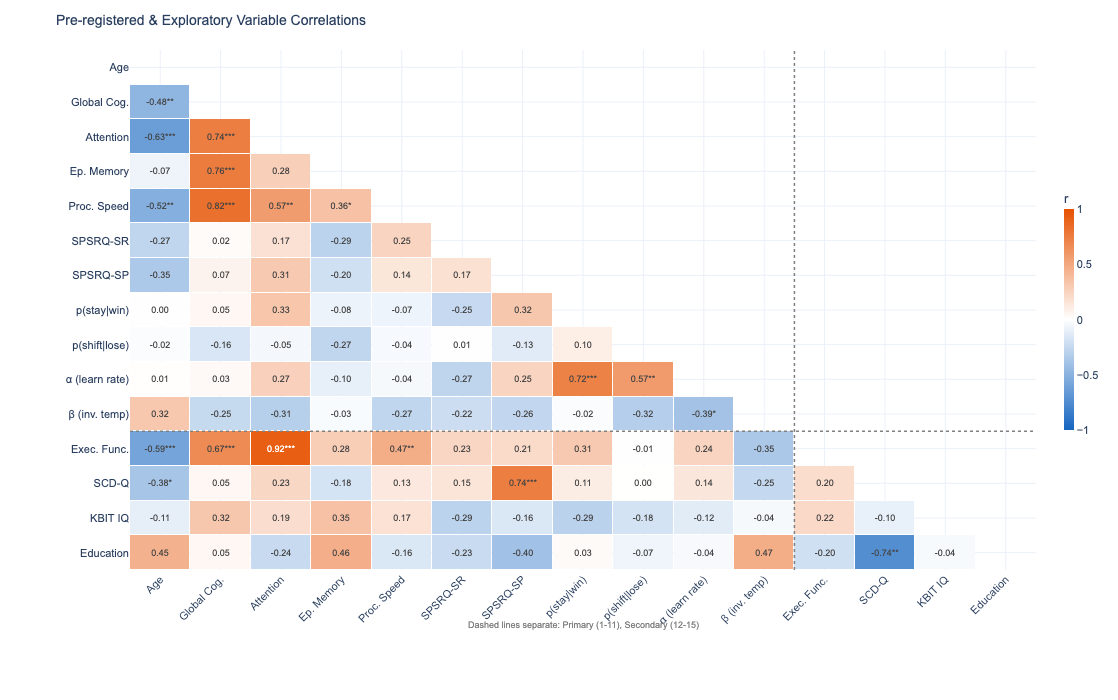

In [38]:
# Pairwise correlations among pre-registered variables
corr_results = run_correlation_analysis(subj_df, include_tertiary=False)

---
## 12. Summary

In [ ]:
print('='*70)
print('ANALYSIS SUMMARY')
print('='*70)
print()

# Sample
print(f'Sample: N = {len(subj_df)}')
print(f'  H1-eligible (sham): {data_h1["subject_id"].nunique()}')
print(f'  H2-eligible (paired): {len(h2_eligible)}')
print()

# Blinding
if blinding_results['blinding_intact']:
    print('✓ Blinding intact')
else:
    print('⚠ Blinding concern')

# Order effects
if order_results['any_significant_order']:
    print('⚠ Significant order × condition interaction')
else:
    print('✓ No significant order effects')
print()

# H2.1 summary
print('H2.1 Paired Comparisons (tACS vs. Sham):')
for param, res in hyp_results['h2_1'].items():
    if res is not None:
        sig = '*' if res['p'] < 0.05 else ''
        print(f"  {param}: dz = {res['dz']:.3f}, p = {res['p']:.3f} {sig}")

---
## Module Reference

| Module | Purpose |
|--------|--------|
| `config.py` | Paths, SUBJECT_INFO, colors, constants |
| `data_loading.py` | Load and preprocess behavioral data |
| `exclusions.py` | Apply behavioral and stim exclusion criteria |
| `sample_descriptives.py` | Demographics, age distribution, cap size |
| `blinding_analysis.py` | Signal detection analysis of blinding |
| `wsls.py` | Win-stay/lose-shift analysis |
| `reversal_analysis.py` | Reversal-locked accuracy curves |
| `rescorla_wagner.py` | R-W model fitting (MLE/MAP) |
| `ddm.py` | Drift diffusion model fitting |
| `cognitive_merge.py` | External data integration, composites |
| `hypothesis_tests.py` | H1.1, H1.2, H2.1, H2.2 tests |
| `order_effects.py` | Counterbalance and session effects |
| `correlations.py` | Correlation heatmap |
| `plotting_utils.py` | Shared visualization utilities |